In [9]:
# set up main path where everything will be you should download the
# hugging face directory described in readme and put it here on the same
# server where the data analyzer is run so that the data analyzer code with 
# the GPU can access these files
# You should replace the below path with your location

import os,torch
import numpy as np
import matplotlib.pyplot as plt
import warnings
from glob import glob
import json
import sys
try:
    with open('../conf/config.json', 'r') as f:
        config = json.load(f)
    storage_path = config['storage_path']
    data_path = config['data_path']
    derivatives_path = config['derivatives_path']
    fsl_path = config['fsl_path']
    project_path = config['project_path']
    assert os.path.exists(storage_path), "The specified storage path does not exist."
    assert os.path.exists(data_path), "The specified data path does not exist."
    assert os.path.exists(derivatives_path), "The specified derivatives path does not exist."
    assert os.path.exists(fsl_path), "The specified FSL path does not exist."
    assert os.path.exists(project_path), "The specified project path does not exist."
except FileNotFoundError:
    raise FileNotFoundError("config.json file not found. Please create it with the required paths.")

# Seed everything
sys.path.append(f'{project_path}/models/generative_models')
sys.path.append(f'{project_path}/models')
import utils_mindeye

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


11
/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats_rt/sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune/sanity_check_individual_reps/pair_0_1_22


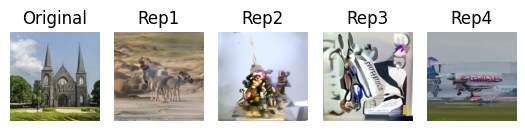

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


pair_0_1_22
/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats_rt/sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune/sanity_check_individual_reps/pair_0_1_78


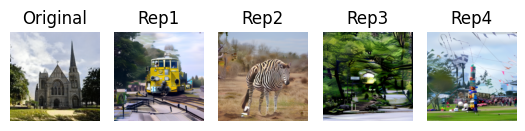

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


pair_0_1_78
/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats_rt/sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune/sanity_check_individual_reps/pair_10_14_33


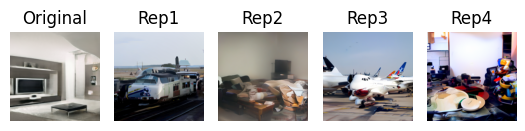

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


pair_10_14_33
/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats_rt/sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune/sanity_check_individual_reps/pair_10_14_89


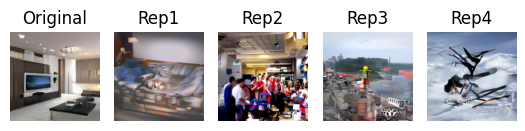

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


pair_10_14_89
/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats_rt/sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune/sanity_check_individual_reps/pair_11_15_44


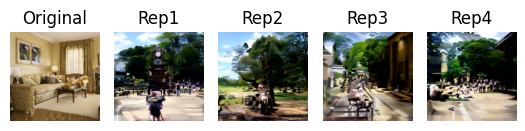

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


pair_11_15_44
/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats_rt/sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune/sanity_check_individual_reps/pair_11_15_89


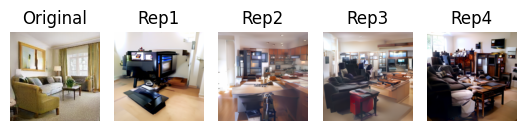

pair_11_15_89


In [31]:
# load and display all recons with originals
model_name = 'sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune'# 'sub-005_ses-01_task-C_bs24_MST_rishab_repeats_3split_3_avgrepeats_finalmask_epochs_45' #'sub-005_ses-01_task-C_bs24_MST_rishab_MSTsplit_3_avgrepeats_finalmask_epochs_45' #'sub-005_ses-01-03_task-C_bs24_MST_rishab_MSTsplit_unionmask_ses-01-03_finetune' #'sub-005_ses-01_task-C_bs24_MST_rishab_MSTsplit_3_avgrepeats_finalmask_epochs_45'
recons_path = f'/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats_rt/{model_name}/sanity_check_individual_reps/*'
# recons_rt_path = f'/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-03_task-C_recons_byrepeats_rt/{model_name}/sanity_check_individual_reps/special*'

folders = sorted(glob(recons_path))
print(len(folders))
for folder in folders[:6]:
    print(folder)
    for curr_recons_path in [recons_path]:
        save_path = os.path.join(curr_recons_path,folder)
        all_ground_truth_save = torch.load(os.path.join(save_path, "all_ground_truth.pt"))
        all_recons_save = torch.load(os.path.join(save_path, "all_recons.pt"))
        plt.figure()
        plt.subplot(1, 6, 1)
        plt.title("Original")
        plt.imshow(all_ground_truth_save[0].numpy().transpose(1, 2, 0), cmap='gray')
        plt.axis('off')  # Hide axes

        for i in range(len(all_recons_save)): 
            plt.subplot(1, 6, i+2)
            plt.title(f"Rep{i+1}")
            plt.imshow(all_recons_save[i].numpy().transpose(1, 2, 0), cmap='gray')
            plt.axis('off')  # Hide axes
        plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(save_path,'All_reps.png'),
            bbox_inches='tight', 
            pad_inches=0)
    plt.close('all')
    print(os.path.basename(save_path))


In [7]:
folders

['sanity_check_individual_reps',
 'special_11942',
 'special_15364',
 'special_16344',
 'special_21108',
 'special_21192',
 'special_22523',
 'special_22794',
 'special_23715',
 'special_23729',
 'special_24846',
 'special_25746',
 'special_26990',
 'special_27568',
 'special_27878',
 'special_28349',
 'special_28755',
 'special_29381',
 'special_30563',
 'special_30856',
 'special_31659',
 'special_34850',
 'special_3489',
 'special_36945',
 'special_36974',
 'special_40721',
 'special_42166',
 'special_42851',
 'special_44705',
 'special_4786',
 'special_48374',
 'special_51077',
 'special_52394',
 'special_52931',
 'special_53370',
 'special_5338',
 'special_55669',
 'special_5602',
 'special_56723',
 'special_59699',
 'special_60251',
 'special_61797',
 'special_62015',
 'special_67237',
 'special_67295',
 'special_7007',
 'special_70232',
 'special_71450',
 'special_71894',
 'special_7366',
 'special_7859']

In [ ]:
# # load and display all recons with originals
# # save_path = '/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats/pair_43_w_lighthouse1'
# # save_path = '/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats/pair_0_1_22'
# save_path = '/teamspace/studios/this_studio/rtcloud-projects/mindeye/derivatives/sub-005_ses-06_task-C_recons_byrepeats/pair_10_14_33'
# all_ground_truth_save = torch.load(os.path.join(save_path, "all_ground_truth.pt"))
# all_recons_save = torch.load(os.path.join(save_path, "all_recons.pt"))
# for i in range(len(all_recons_save)):
#     plt.figure(figsize=(10, 5))
#     plt.subplot(1, 2, 1)
#     plt.title("Original Image")
#     plt.imshow(all_ground_truth_save[i].numpy().transpose(1, 2, 0), cmap='gray')
#     plt.axis('off')  # Hide axes
#     plt.subplot(1, 2, 2)
#     plt.title("Reconstructed Image")
#     plt.imshow(all_recons_save[i].numpy().transpose(1, 2, 0), cmap='gray')
#     plt.axis('off')  # Hide axes

#     plt.show()
